In [ ]:
import numpy as np
import maglab
import torch
import torch.nn.functional as F

def remove_background(phase, mask, ):
    # we need to compare the phase shift after removal of low-frequency signal, so we apply a gauss kernel filter on the images.
    gauss_kernel_size = 99
    sigma = maglab.preprocess.compute_sigma(gauss_kernel_size)
    kernel = maglab.preprocess.gaussian_kernel(gauss_kernel_size, sigma)
    kernel_groups = kernel.repeat(8, 1, 1, 1).cuda()
    phase_blurred = F.conv2d(phase, kernel_groups, groups=8, padding=gauss_kernel_size // 2)
    return (mask * (phase - phase_blurred))

def delta_phi(phi1, phi2):
    phi1 = phi1.detach().cpu().numpy()
    phi2 = phi2.detach().cpu().numpy()
    delta = np.sum(abs(phi1 - phi2))# / np.mean(abs(phi1))
    return delta

N = 206
dx = 1.06e-9
geo = maglab.geo.cylider(136, 111)
nx, ny, nz = geo.shape
Ms = 3.84e5
micro = maglab.Micro(nx, ny, nz, dx)

alphas = [0, 28, 44, 50, 54, 58, 61, 65]
phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()
phaseset = maglab.dataset.PhaseSet()

for alpha in alphas:
    phasemap = torch.load(f"D:\\Projects\\TargetSkyrmion\\targetdata\\dataset\\dm3_refin\\refin_3dmask_pm\\phasemap_{alpha}.pth", weights_only=False)
    for item in phasemap:
        data  = item['data'].transpose((1,0))
        mask  = item['mask'].transpose((1,0))
        alpha = -item['alpha']
        phasemap = maglab.dataset.PhaseMap(data=data, mask=mask, alpha=alpha)
    phaseset.load(phasemap)
phaseset.sort()

phase_exeperiments = torch.stack([x.data for x in phaseset]).cuda()
mask = torch.stack([phasemap.mask for phasemap in phaseset]).cuda()
alphas = [x.Euler[0] for x in phaseset]
betas = [x.Euler[1] for x in phaseset]
num_phase = len(phaseset)

losses = [0,2,4,6,8,10,12,14,16,18,20]
ws = [10**0, 10**0.5, 10**1, 10**1.5, 10**2, 10**2.5, 10**3, 10**3.5, 10**4, 10**4.5, 10**5, 10**5.5, 10**6, 10**6.5, 10**7, 10**7.5, 10**8, 10**8.5, 10**9]

for l in losses:
    energy_values = []
    phi_loss_values = []
    for w in ws:
        if l == 0:
            base_path = f'D:\\Projects\\TargetSkyrmion\\targetdata\\1test_phi\\results\\loss0.0e+00_wphi{w:.1e}'
        else:
            base_path = f'D:\\Projects\\TargetSkyrmion\\targetdata\\3dmi_loss\\{l}_layers_loss\\results\\loss{l:.1e}_wphi{w:.1e}'
        file_path = base_path.format(w=w)
        w1, w2 = 1, w
        try:
            s = micro.load_state(f"{file_path}\\final.pth")
            spin2 = s.get_spin().cuda()
            energy_density = s.get_energy_density(spin2)
            tot_energy = float(torch.sum(energy_density)) * s.dx**3

            phase_pred = torch.stack([phasemapper(spin2, 
                                                    alpha=alphas[i], 
                                                    beta=betas[i], 
                                                    Ms=Ms) 
                                        for i in range(num_phase)])

            phi_loss = delta_phi(remove_background(phase_exeperiments, mask), remove_background(phase_pred, mask))
            phi_loss_value = phi_loss
            
            energy_values.append(tot_energy)
            phi_loss_values.append(phi_loss_value)

        except Exception as e:
            print(f"Error processing w={np.log10(w)}: {e}")
            energy_values.append(np.nan)
            phi_loss_values.append(np.nan)
            
    Lm = np.array(energy_values)*1e17
    Lphi = np.array(phi_loss_values)

    with open(f'{l}loss.txt', 'w') as f:
        f.write("n, Lm, Lphi\n")
        for i, w in enumerate(ws):
            f.write(f"{np.log10(w)}, {Lm[i]}, {Lphi[i]}\n")
    print(f"数据已保存到 {l}loss.txt 文件中")


数据已保存到 0loss.txt 文件中
数据已保存到 2loss.txt 文件中
数据已保存到 4loss.txt 文件中
数据已保存到 6loss.txt 文件中
数据已保存到 8loss.txt 文件中
数据已保存到 10loss.txt 文件中
数据已保存到 12loss.txt 文件中
数据已保存到 14loss.txt 文件中
数据已保存到 16loss.txt 文件中
数据已保存到 18loss.txt 文件中
数据已保存到 20loss.txt 文件中


file 0loss.txt totloss 0.06151055089019298
已保存文件: 0loss.csv
file 10loss.txt totloss 0.07513159094643426
已保存文件: 10loss.csv
file 12loss.txt totloss 0.0744386163709169
已保存文件: 12loss.csv
file 14loss.txt totloss 0.03312819221553865
已保存文件: 14loss.csv
file 16loss.txt totloss 0.07132115374783494
已保存文件: 16loss.csv
file 18loss.txt totloss 0.06111269636323316
已保存文件: 18loss.csv
file 20loss.txt totloss 0.06014347665851044
已保存文件: 20loss.csv
file 2loss.txt totloss 0.0558639996790269
已保存文件: 2loss.csv
file 4loss.txt totloss 0.0757204032373763
已保存文件: 4loss.csv
file 6loss.txt totloss 0.07670174318175554
已保存文件: 6loss.csv
file 8loss.txt totloss 0.035862189386842096
已保存文件: 8loss.csv


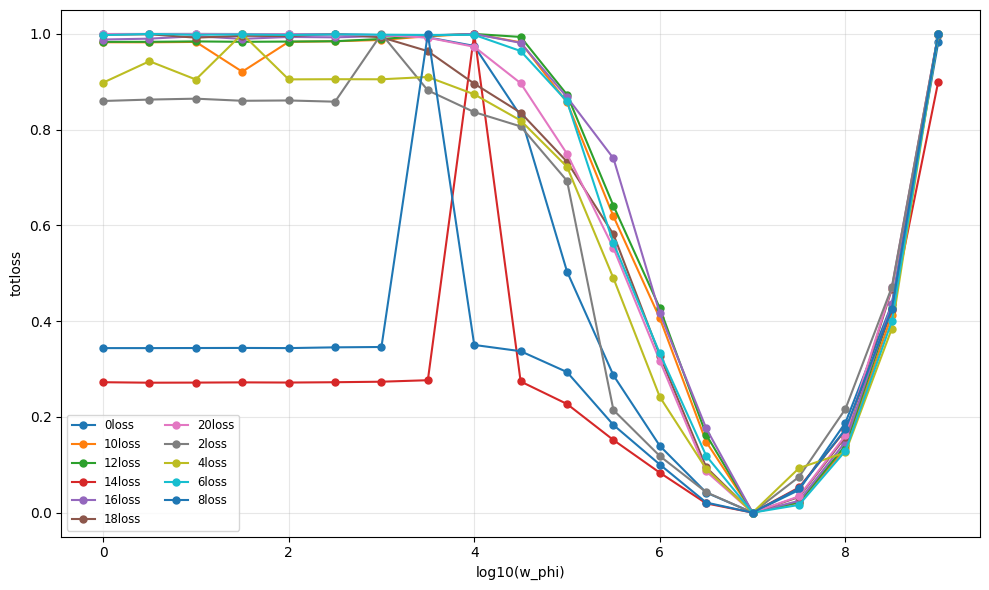

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import csv

files = sorted([fn for fn in os.listdir('.') if fn.endswith('loss.txt')])
if not files:
    print("none '*loss.txt' files")
else:
    all_data = {}
    def normalize(arr):
        mn = np.nanmin(arr)
        mx = np.nanmax(arr)
        if np.isclose(mx, mn):
            return np.zeros_like(arr)
        return (arr - mn) / (mx - mn)

    for fn in files:
        xs = []
        Lm = []
        Lphi = []
        Ltotal_file = []
        with open(fn, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        for line in lines[1:]: 
            parts = line.replace(',', ' ').strip().split()
            if len(parts) < 3:
                continue
            try:
                x = float(parts[0])
                lm = float(parts[1])*1e17
                lphi = float(parts[2])
                ltot = float(parts[3]) if len(parts) > 3 else np.nan
            except Exception:
                continue
            xs.append(x)
            Lm.append(lm)
            Lphi.append(lphi)
            Ltotal_file.append(ltot)

        if len(xs) == 0:
            continue

        xs = np.array(xs)
        Lm = np.array(Lm, dtype=float)
        Lphi = np.array(Lphi, dtype=float)
        Ltotal_file = np.array(Ltotal_file, dtype=float)

        Lm_n = normalize(Lm)
        Lphi_n = normalize(Lphi)
        totloss_calc = normalize(Lm_n + Lphi_n)
        print(f"file {fn} totloss {Lphi_n[15]}")

        csv_filename = fn.replace('.txt', '.csv')
        with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['x', 'totloss_calc'])
            for i in range(len(xs)):
                writer.writerow([
                    xs[i],
                    totloss_calc[i]
                ])
        print(f"已保存文件: {csv_filename}")

        idx = np.argsort(xs)
        all_data[fn] = {
            'x': xs[idx],
            'totloss_calc': totloss_calc[idx],
            'Ltotal_file': Ltotal_file[idx],
            'Lm': Lm[idx],
            'Lphi': Lphi[idx]
        }

    plt.figure(figsize=(10, 6))
    for fn, dat in all_data.items():
        label = fn.replace('.txt', '')
        plt.plot(dat['x'], dat['totloss_calc'], '-o', label=label, linewidth=1.5, markersize=5)

    plt.xlabel('log10(w_phi)')
    plt.ylabel('totloss')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()


[0.99405274 0.98776173 0.99625125 0.99838362 0.99383234 0.98974639
 1.00221315 1.01140052 0.98350955 0.88984581 0.86338073 0.39993717
 0.32316254 0.24861512 0.20589363 0.26338695 0.37607163 0.57553395
 1.        ]


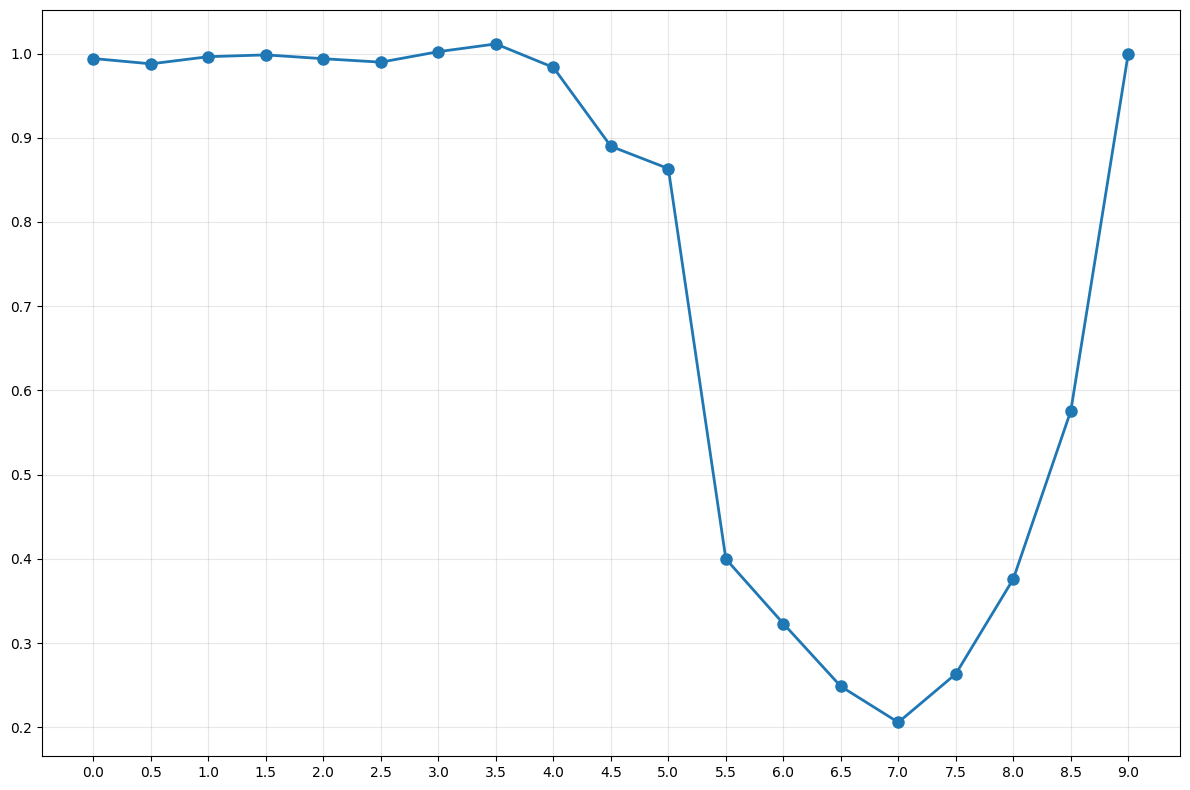

In [13]:
import matplotlib.pyplot as plt
import numpy as np

with open('./2loss.txt', 'r') as file:
    lines = file.readlines()
    data = []
    for line in lines:
        row = [x.replace(',', '') for x in line.strip().split(' ')]
        data.append(row)
ws = []
mloss = []
philoss = []

def delta_phi(phi1, phi2):
    phi1 = phi1#.detach().cpu().numpy()
    phi2 = phi2#.detach().cpu().numpy()
    delta = np.mean(abs(phi1 - phi2)) / np.mean(abs(phi1))
    return delta

for i in range(19):
    ws.append(float(data[1:][i][0]))
    mloss.append(float(data[1:][i][1]))
    philoss.append(float(data[1:][i][2]))

mloss = (mloss - np.min(mloss)) / (np.max(mloss) - np.min(mloss))
philoss = (philoss - np.min(philoss)) / (np.max(philoss) - np.min(philoss))
totloss = (mloss + philoss)
print(totloss)

plt.figure(figsize=(12, 8))
plt.subplot(1, 1, 1)
plt.plot(ws, totloss, 'o-', linewidth=2, markersize=8)
plt.grid(True, alpha=0.3)
plt.xticks(ws)
plt.tight_layout()
plt.show()